<a href="https://colab.research.google.com/github/Chitra9xh/DL-LAB/blob/main/Lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [4]:
#image transformation
transform = transforms.Compose([
    transforms.ToTensor(),#0-255 ->> 0-1

    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

In [5]:
#LOAD CIFAR-10 DATASET
train_dataset_full = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset_full = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

classes = train_dataset_full.classes

print("\nClasses:")
print(classes)

print("\nTotal training images:", len(train_dataset_full))
print("Total testing images:", len(test_dataset_full))

100%|██████████| 170M/170M [45:33<00:00, 62.4kB/s]



Classes:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Total training images: 50000
Total testing images: 10000


In [6]:
train_dataset = train_dataset_full
test_dataset = test_dataset_full

print("\nTraining images:", len(train_dataset))
print("Testing images:", len(test_dataset))


Training images: 50000
Testing images: 10000


In [7]:
#CREATE DATA LOADERS
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [8]:
#DEFINE CNN MODEL
class CNN(nn.Module):

    def __init__(self):

        super(CNN, self).__init__()

        self.features = nn.Sequential(

            # -------------------------
            # Convolution Block 1
            # -------------------------

            nn.Conv2d(
                in_channels=3,
                out_channels=32,   #image=32x32x3 filter=3x3x32 output=32x32x32
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(), #all negative pixels become zero

            nn.MaxPool2d(
                kernel_size=2  #dim reduction so 32x32x32 becomes 16x16x32
            ),


            # -------------------------
            # Convolution Block 2
            # -------------------------

            nn.Conv2d(
                in_channels=32,
                out_channels=64, #16x16x32 conv with 3x3x64 to get 16x16x64
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2  #16x16x64 becomes 8x8x64
            )
        )


        self.classifier = nn.Sequential(

            nn.Flatten(),  #8x8x64 becomes 4096 single vector

            # Image size:
            # 32 x 32
            #
            # After first pooling:
            # 16 x 16
            #
            # After second pooling:
            # 8 x 8
            #
            # Number of channels = 64

            nn.Linear(      #fully connected layer taking 4096 inputs connected
                64 * 8 * 8, #to 128 neurons
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,  #128 neurons in previous layer connected to 10 output neurons
                10
            )
        )
    def forward(self, x):  #during forward pass call features and then classifier

      x = self.features(x)

      x = self.classifier(x)

      return x

In [10]:
#CREATE MODEL
model = CNN()

model = model.to(device) #take model to gpu or cpu

print("\nCNN Architecture:\n")
print(model)


CNN Architecture:

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [11]:
#LOSS FUNCTION AND OPTIMIZER
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [12]:
#TRAINING
num_epochs = 5

train_losses = []
train_accuracies = []

print("\nStarting Training...\n")

for epoch in range(num_epochs):

    model.train() #model is being trained, this is imp for dropout and batchnorm layers which don't run duing  testing

    running_loss = 0.0

    correct = 0
    total = 0


    for images, labels in train_loader:

        # Move data to device
        images = images.to(device)
        labels = labels.to(device) #each image has label


        # -------------------------
        # Forward Pass
        # -------------------------

        outputs = model(images)


        # -------------------------
        # Calculate Loss
        # -------------------------

        loss = criterion(
            outputs,
            labels
        )


        # -------------------------
        # Backpropagation
        # -------------------------

        optimizer.zero_grad() #pytorch needs to clear gradients before computing

        loss.backward() #backward propa

        optimizer.step() #updating weights


        # -------------------------
        # Statistics
        # -------------------------

        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0) #labels.size() return  the dimesnion of label tensor i.e. [64] actually 64x1, we want the zeroth dim so 0

        correct += (
            predicted == labels
        ).sum().item()


    # Epoch statistics

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    epoch_accuracy = (
        100 * correct / total
    )

    train_losses.append(
        epoch_loss
    )

    train_accuracies.append(
        epoch_accuracy
    )


    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )


Starting Training...

Epoch [1/5] Loss: 1.3374 Accuracy: 51.87%
Epoch [2/5] Loss: 0.9717 Accuracy: 65.78%
Epoch [3/5] Loss: 0.8254 Accuracy: 71.13%
Epoch [4/5] Loss: 0.7109 Accuracy: 75.03%
Epoch [5/5] Loss: 0.6160 Accuracy: 78.42%


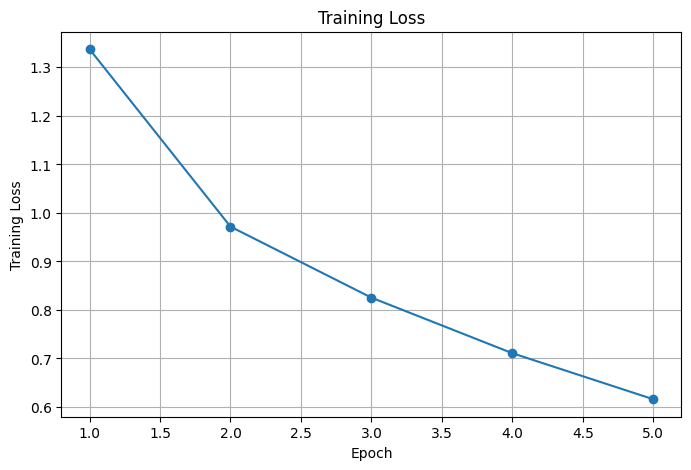

In [13]:
#PLOT TRAINING LOSS
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title("Training Loss")

plt.grid()

plt.show()

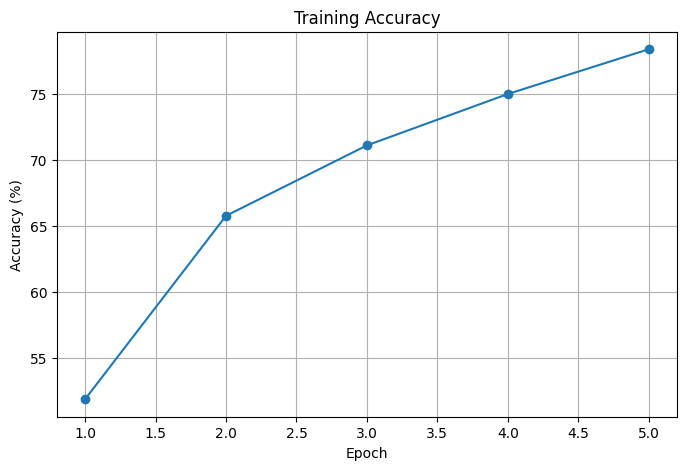

In [14]:
# PLOT TRAINING ACCURACY
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_accuracies,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title("Training Accuracy")

plt.grid()

plt.show()

In [15]:
#EVALUATE MODEL ON TEST SET
model.eval()

correct = 0
total = 0

all_labels = []
all_predictions = []


with torch.no_grad(): #we don't want model to compute gradients during eval mode; we want only in training mode

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)


        # Forward pass

        outputs = model(images)


        # Predicted class

        _, predicted = torch.max(
            outputs,
            1
        )


        # Accuracy

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


        # Store labels and predictions

        all_labels.extend( #extend will add more values to the existing array. [1,2,3] -> [1,2,3,4,5,6]
            labels.cpu().numpy()  #keeping labels on cpu as numpy works on cpu and converting tensors to numpy arrays
        )

        all_predictions.extend( # needed for confusion matrix
            predicted.cpu().numpy()
        )


test_accuracy = (
    100 * correct / total
)


print(
    f"\nTest Accuracy: "
    f"{test_accuracy:.2f}%"
)


Test Accuracy: 71.96%


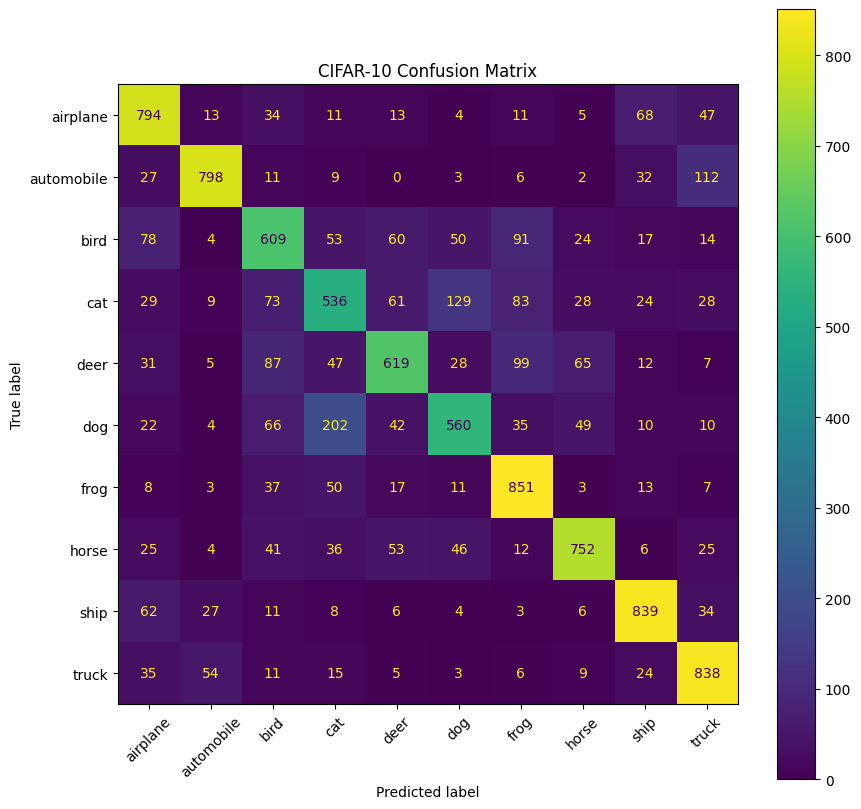

In [16]:
#CONFUSION MATRIX
cm = confusion_matrix(
    all_labels,
    all_predictions
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)


fig, ax = plt.subplots(
    figsize=(10, 10) #10 inch by 10 inch
)


disp.plot(
    ax=ax,
    xticks_rotation=45
)


plt.title(
    "CIFAR-10 Confusion Matrix"
)

plt.show()

In [17]:
#CLASS-WISE ACCURACY
print("\nClass-wise Accuracy:\n")

for i, class_name in enumerate(classes):

    class_total = cm[i].sum()

    class_correct = cm[i, i]

    accuracy = (
        100 * class_correct /
        class_total
        if class_total > 0
        else 0
    )

    print(
        f"{class_name:10s}: "
        f"{accuracy:.2f}%"
    )


Class-wise Accuracy:

airplane  : 79.40%
automobile: 79.80%
bird      : 60.90%
cat       : 53.60%
deer      : 61.90%
dog       : 56.00%
frog      : 85.10%
horse     : 75.20%
ship      : 83.90%
truck     : 83.80%
